# Initial Data Exploration
## Imports and load raw_data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("../../energy-demand-forecasting/data/01_raw/raw_data.parquet")
df

,cod_areacarga,dat_referencia,din_referenciautc,val_cargaglobalprogramada
0,SECO,2020-12-01,2020-12-01T03:30:00.000Z,42599.760
1,SECO,2020-12-01,2020-12-01T04:00:00.000Z,41504.188
2,SECO,2020-12-01,2020-12-01T04:30:00.000Z,40345.900
3,SECO,2020-12-01,2020-12-01T05:00:00.000Z,39503.660
4,SECO,2020-12-01,2020-12-01T05:30:00.000Z,38824.410
...,...,...,...,...
373723,S,2026-06-30,2026-07-01T01:00:00.000Z,15704.043
373724,S,2026-06-30,2026-07-01T01:30:00.000Z,15017.254
373725,S,2026-06-30,2026-07-01T02:00:00.000Z,14283.808
373726,S,2026-06-30,2026-07-01T02:30:00.000Z,13533.600


## Describe (distribution and count nan values)
### raw_data

In [3]:
df.describe()

,val_cargaglobalprogramada
count,373728.000000
mean,18828.462333
std,14344.986148
min,4615.929000
25%,8861.058000
50%,12648.011000
75%,28092.231000
max,62639.530000


### separated by area

In [4]:
df_wide = df.pivot(
    index=["dat_referencia", "din_referenciautc"],
    columns="cod_areacarga",
    values="val_cargaglobalprogramada"
).reset_index()

df_wide.columns.name = None

df_wide

,dat_referencia,din_referenciautc,N,NE,S,SECO
0,2020-12-01,2020-12-01T03:30:00.000Z,NaN,NaN,NaN,42599.760
1,2020-12-01,2020-12-01T04:00:00.000Z,NaN,NaN,NaN,41504.188
2,2020-12-01,2020-12-01T04:30:00.000Z,NaN,NaN,NaN,40345.900
3,2020-12-01,2020-12-01T05:00:00.000Z,NaN,NaN,NaN,39503.660
4,2020-12-01,2020-12-01T05:30:00.000Z,NaN,NaN,NaN,38824.410
...,...,...,...,...,...,...
93643,2026-06-30,2026-07-01T01:00:00.000Z,9222.3955,14951.530,15704.043,48843.062
93644,2026-06-30,2026-07-01T01:30:00.000Z,9279.2460,14901.305,15017.254,47211.030
93645,2026-06-30,2026-07-01T02:00:00.000Z,9284.3210,14753.794,14283.808,45498.310
93646,2026-06-30,2026-07-01T02:30:00.000Z,9236.8340,14495.394,13533.600,43538.508


In [5]:
df_wide.describe()

,N,NE,S,SECO
count,93408.000000,93360.000000,93408.000000,93552.000000
mean,7243.983824,12454.931576,13023.263281,42551.822959
std,1070.424516,1556.595133,2655.466203,6362.069766
min,4615.929000,7413.211400,5995.534000,25792.441000
25%,6343.601500,11352.504250,10957.497750,37761.652500
50%,7301.701300,12425.408000,13045.889500,42493.468500
75%,8078.294125,13606.085500,14878.285000,47124.354250
max,10625.137000,16962.610000,22474.654000,62639.530000


## Dataviz

In [6]:
cols = ["N", "NE", "S", "SECO"]

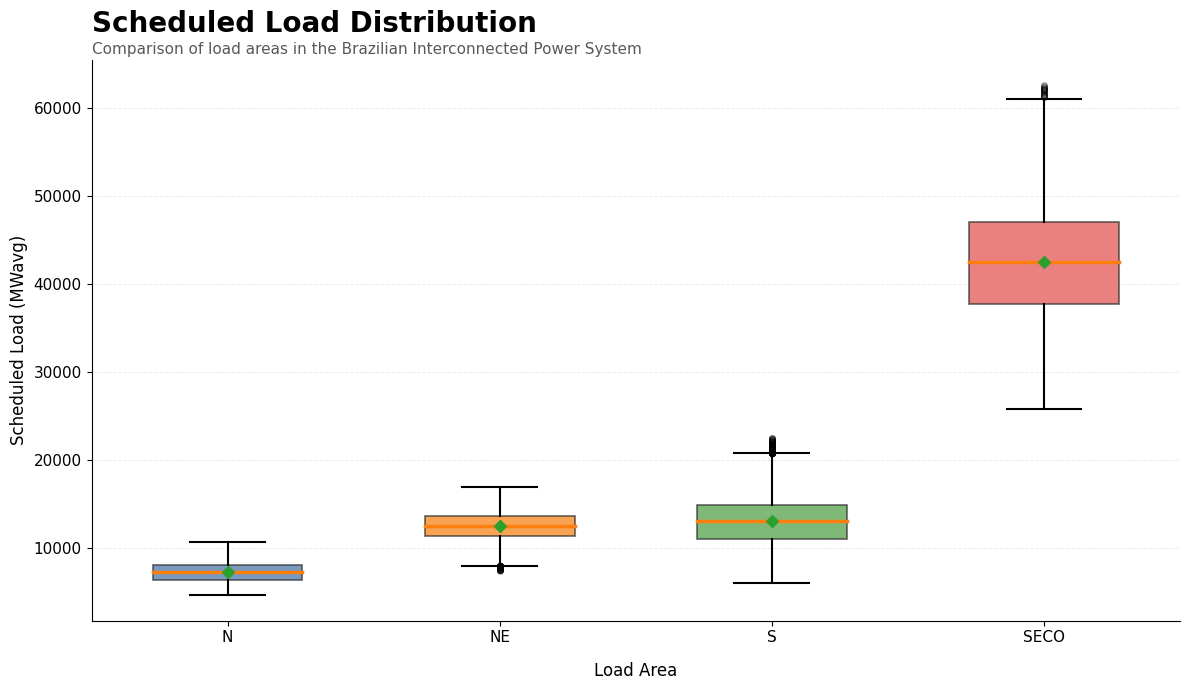

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

data = [df_wide[c].dropna() for c in cols]

bp = ax.boxplot(
    data,
    patch_artist=True,
    widths=0.55,
    showmeans=True,
    labels=cols,

    medianprops={
        "linewidth": 2.5,
    },

    meanprops={
        "marker": "D",
        "markersize": 6,
        "markeredgewidth": 1,
    },

    whiskerprops={
        "linewidth": 1.5,
    },

    capprops={
        "linewidth": 1.5,
    },

    flierprops={
        "marker": "o",
        "markersize": 4,
        "alpha": 0.3,
    },
)

colors = [
    "#4C78A8",
    "#F58518",
    "#54A24B",
    "#E45756",
]

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor("#333333")
    patch.set_linewidth(1.2)

ax.set_title(
    "Scheduled Load Distribution",
    fontsize=20,
    fontweight="bold",
    loc="left",
    pad=20,
)

ax.text(
    0,
    1.01,
    "Comparison of load areas in the Brazilian Interconnected Power System",
    transform=ax.transAxes,
    fontsize=11,
    alpha=0.65,
)

ax.set_ylabel(
    "Scheduled Load (MWavg)",
    fontsize=12,
)

ax.set_xlabel(
    "Load Area",
    fontsize=12,
    labelpad=12,
)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="both",
    labelsize=11,
)

plt.tight_layout()
plt.show()

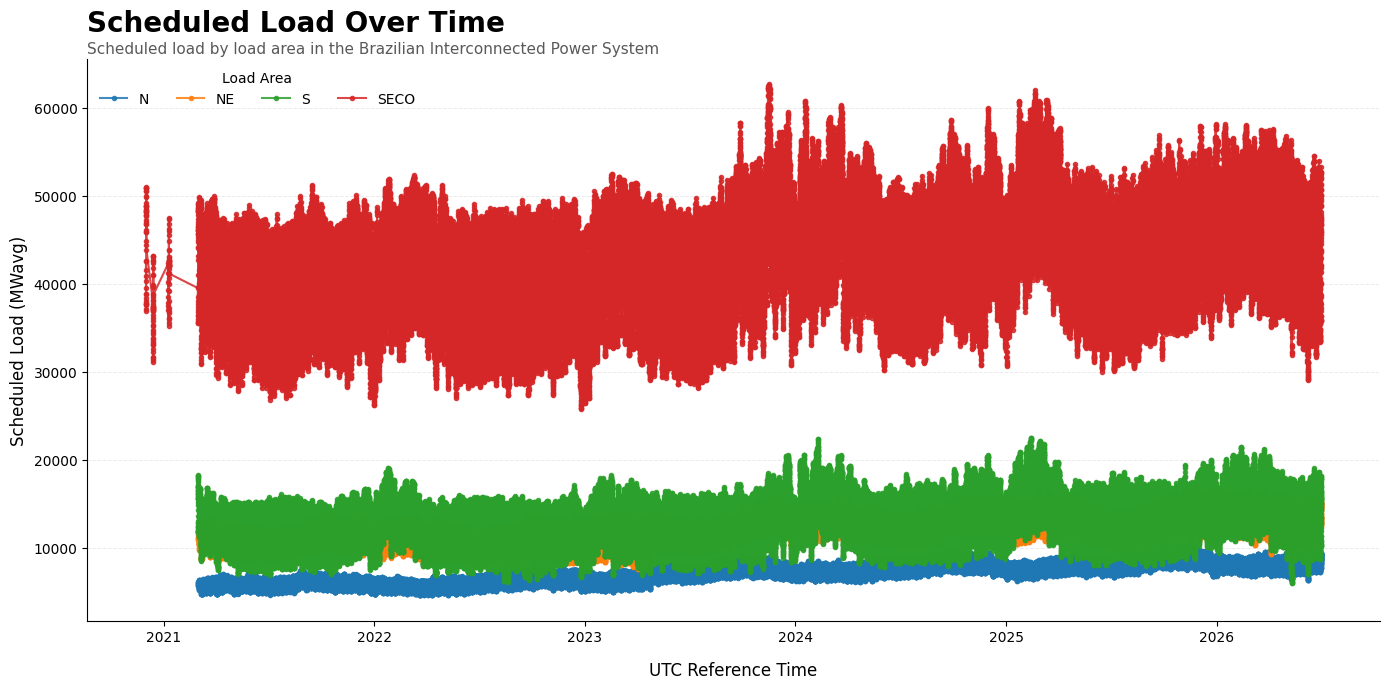

In [8]:
df_wide["din_referenciautc"] = pd.to_datetime(
    df_wide["din_referenciautc"]
)

df_plot = df_wide.sort_values("din_referenciautc")

fig, ax = plt.subplots(figsize=(14, 7))

for area in cols:
    ax.plot(
        df_plot["din_referenciautc"],
        df_plot[area],
        marker="o",
        markersize=3,
        linewidth=1.5,
        alpha=0.85,
        label=area,
    )

ax.set_title(
    "Scheduled Load Over Time",
    fontsize=20,
    fontweight="bold",
    loc="left",
    pad=20,
)

ax.text(
    0,
    1.01,
    "Scheduled load by load area in the Brazilian Interconnected Power System",
    transform=ax.transAxes,
    fontsize=11,
    alpha=0.65,
)

ax.set_xlabel(
    "UTC Reference Time",
    fontsize=12,
    labelpad=12,
)

ax.set_ylabel(
    "Scheduled Load (MWavg)",
    fontsize=12,
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Load Area",
    frameon=False,
    ncol=4,
)

plt.tight_layout()
plt.show()